In [46]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# Loading dataset for initial inspections
df = pd.read_csv("agro_moisture_dataset.csv")

df.head() 

,Sensor_ID,Date,Soil_Moisture(%),Soil_pH,Temperature(C),Humidity(%),Crop_Type,Fertilizer_Recommended(kg/ha),Irrigation_Recommended(mm),Drone_Image_ID
0,SEN-1000,2025-01-01,36.22,6.98,21.3,50.4,Tomatoes,67.6,26.6,IMG-2000
1,SEN-1001,2025-01-02,76.55,5.03,23.5,34.3,Wheat,130.4,8.3,IMG-2001
2,SEN-1002,2025-01-03,61.24,6.52,21.9,54.6,Tomatoes,36.0,29.4,IMG-2002
3,SEN-1003,2025-01-04,51.91,6.62,24.0,48.7,Maize,85.8,19.6,IMG-2003
4,SEN-1004,2025-01-05,20.92,5.98,19.2,70.6,Wheat,75.6,29.9,IMG-2004


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913 entries, 0 to 912
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Sensor_ID                      913 non-null    object
 1   Date                           909 non-null    object
 2   Soil_Moisture(%)               913 non-null    object
 3   Soil_pH                        913 non-null    object
 4   Temperature(C)                 913 non-null    object
 5   Humidity(%)                    913 non-null    object
 6   Crop_Type                      909 non-null    object
 7   Fertilizer_Recommended(kg/ha)  913 non-null    object
 8   Irrigation_Recommended(mm)     913 non-null    object
 9   Drone_Image_ID                 913 non-null    object
dtypes: object(10)
memory usage: 71.5+ KB


In [49]:
#Descriptive Statistics
df.describe()

,Sensor_ID,Date,Soil_Moisture(%),Soil_pH,Temperature(C),Humidity(%),Crop_Type,Fertilizer_Recommended(kg/ha),Irrigation_Recommended(mm),Drone_Image_ID
count,913,909,913,913,913,913,909,913,913,913
unique,800,798,750,313,170,448,5,595,243,800
top,SEN-1430,2026-09-10,error,7.54,19.1,56.0,Wheat,66.9,8.0,IMG-2430
freq,2,2,5,11,13,8,203,8,11,2


In [50]:
#Cleaning Data

#Checking missing values
print("------MISSING VALUES------")
df.isnull().sum()

------MISSING VALUES------


Sensor_ID                        0
Date                             4
Soil_Moisture(%)                 0
Soil_pH                          0
Temperature(C)                   0
Humidity(%)                      0
Crop_Type                        4
Fertilizer_Recommended(kg/ha)    0
Irrigation_Recommended(mm)       0
Drone_Image_ID                   0
dtype: int64

In [51]:

#Handling invalid values and missing values

#Numerical columns are filled with median or mean
numeric_cols = ['Soil_Moisture(%)','Soil_pH','Temperature(C)','Humidity(%)','Fertilizer_Recommended(kg/ha)','Irrigation_Recommended(mm)']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce') #changing invalid values to NaN
        x = df[col].median()
        df[col] = df[col].fillna(x) #filling NaN with median
    
        
 #categorical values are filled with mode   
categorical_cols = ['Crop_Type'] 
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])
        
#Changing Date Format
df['Date'] = pd.to_datetime(df['Date'], errors = 'coerce')
df['Date'] = df['Date'].bfill()
        
#checking for missing values again
print("------MISSING VALUES------")
df.isnull().sum()



------MISSING VALUES------


Sensor_ID                        0
Date                             0
Soil_Moisture(%)                 0
Soil_pH                          0
Temperature(C)                   0
Humidity(%)                      0
Crop_Type                        0
Fertilizer_Recommended(kg/ha)    0
Irrigation_Recommended(mm)       0
Drone_Image_ID                   0
dtype: int64

In [52]:
#Handling Wrong data

factor_cols = ['Soil_Moisture(%)','Soil_pH','Temperature(C)','Humidity(%)','Fertilizer_Recommended(kg/ha)','Irrigation_Recommended(mm)']
for col in factor_cols:
    if col in df.columns:
        mean = df[col].mean()
        std = df[col].std()
        df[col] = np.where((df[col] < mean - 3*std) | (df[col] > mean + 3*std), np.nan, df[col])
        df[col] = df[col].fillna(df[col].median())

In [53]:
#checking for duplicates
print("------DUPLICATED ROWS------")
print(df.duplicated().sum())

------DUPLICATED ROWS------
111


In [54]:
#removing duplicates
df = df.drop_duplicates()
print("number of rows and columns after removing duplicates:",df.shape)

#checking Date duplicates
print("Date duplicates:",df['Date'].duplicated().sum())

#drop the duplicates
df = df.drop_duplicates(subset = ['Date'], keep = 'first')

print('Shape:',df.shape)


number of rows and columns after removing duplicates: (802, 10)
Date duplicates: 4
Shape: (798, 10)


In [55]:
df.info()
print("-------------------------------------")
print("Missing values after cleaning")
print(df.isnull().sum())
df.to_csv("cleaned_agro_moisture_dataset.csv")

<class 'pandas.core.frame.DataFrame'>
Index: 798 entries, 0 to 863
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Sensor_ID                      798 non-null    object        
 1   Date                           798 non-null    datetime64[ns]
 2   Soil_Moisture(%)               798 non-null    float64       
 3   Soil_pH                        798 non-null    float64       
 4   Temperature(C)                 798 non-null    float64       
 5   Humidity(%)                    798 non-null    float64       
 6   Crop_Type                      798 non-null    object        
 7   Fertilizer_Recommended(kg/ha)  798 non-null    float64       
 8   Irrigation_Recommended(mm)     798 non-null    float64       
 9   Drone_Image_ID                 798 non-null    object        
dtypes: datetime64[ns](1), float64(6), object(3)
memory usage: 68.6+ KB
------------------------

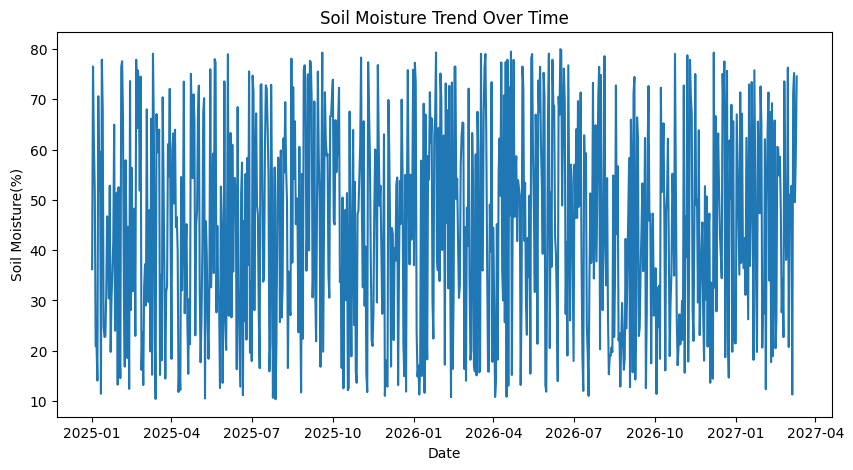

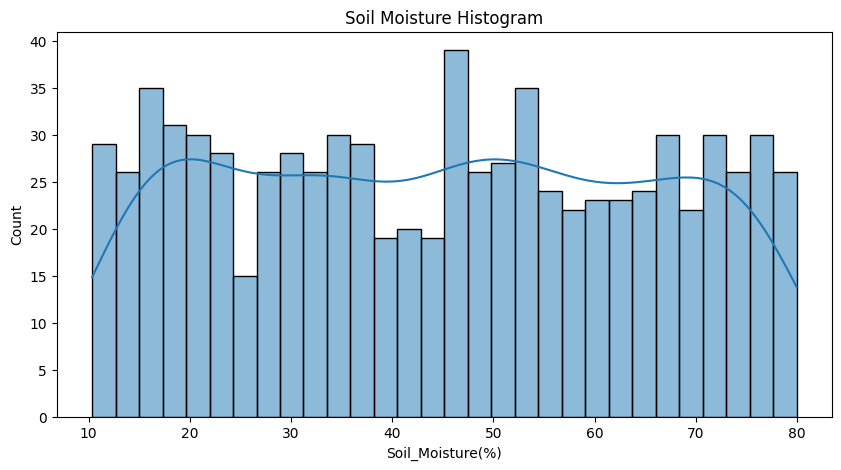

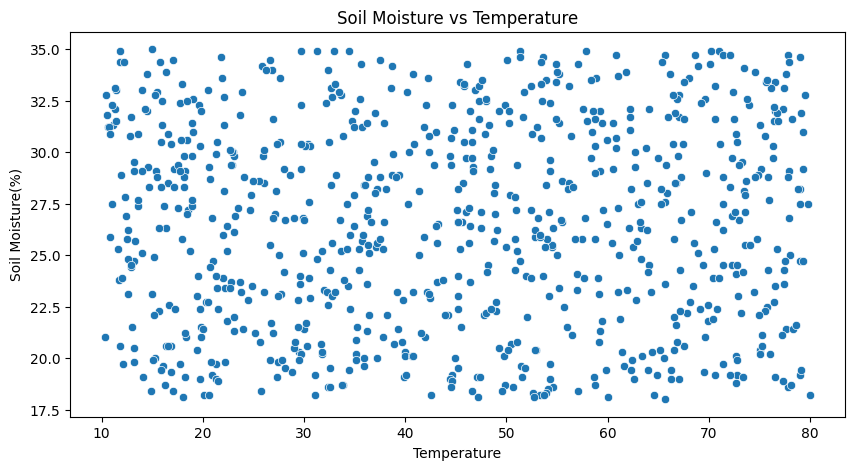

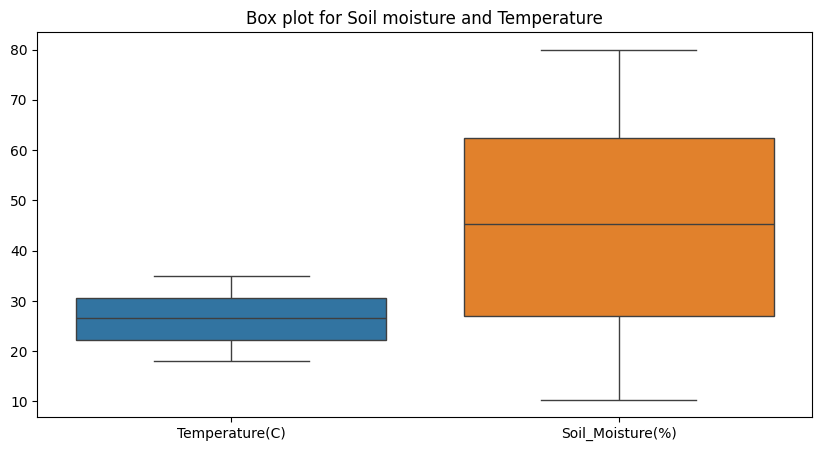

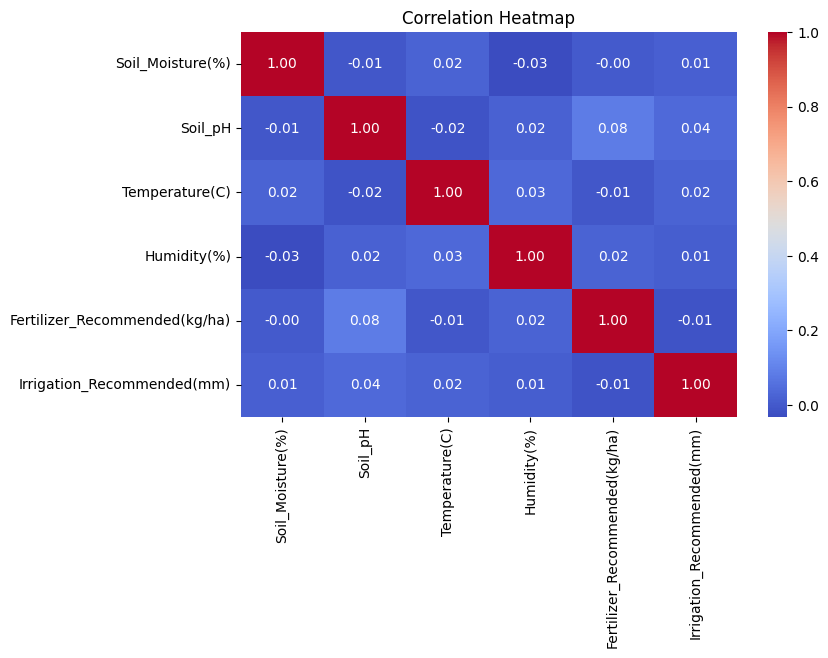

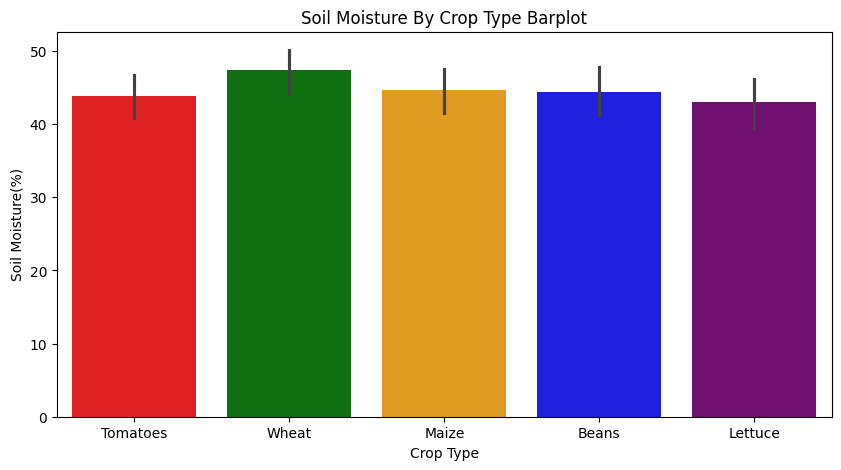

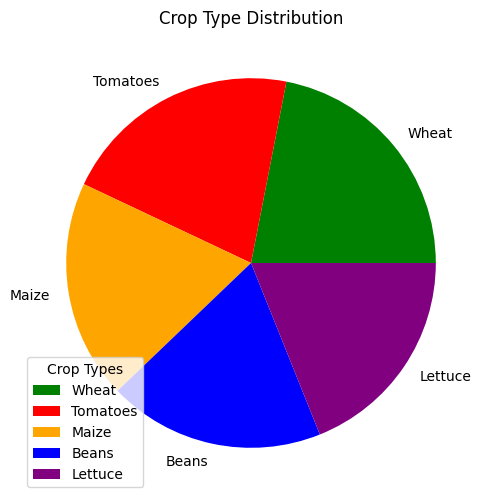

<Figure size 1000x500 with 0 Axes>

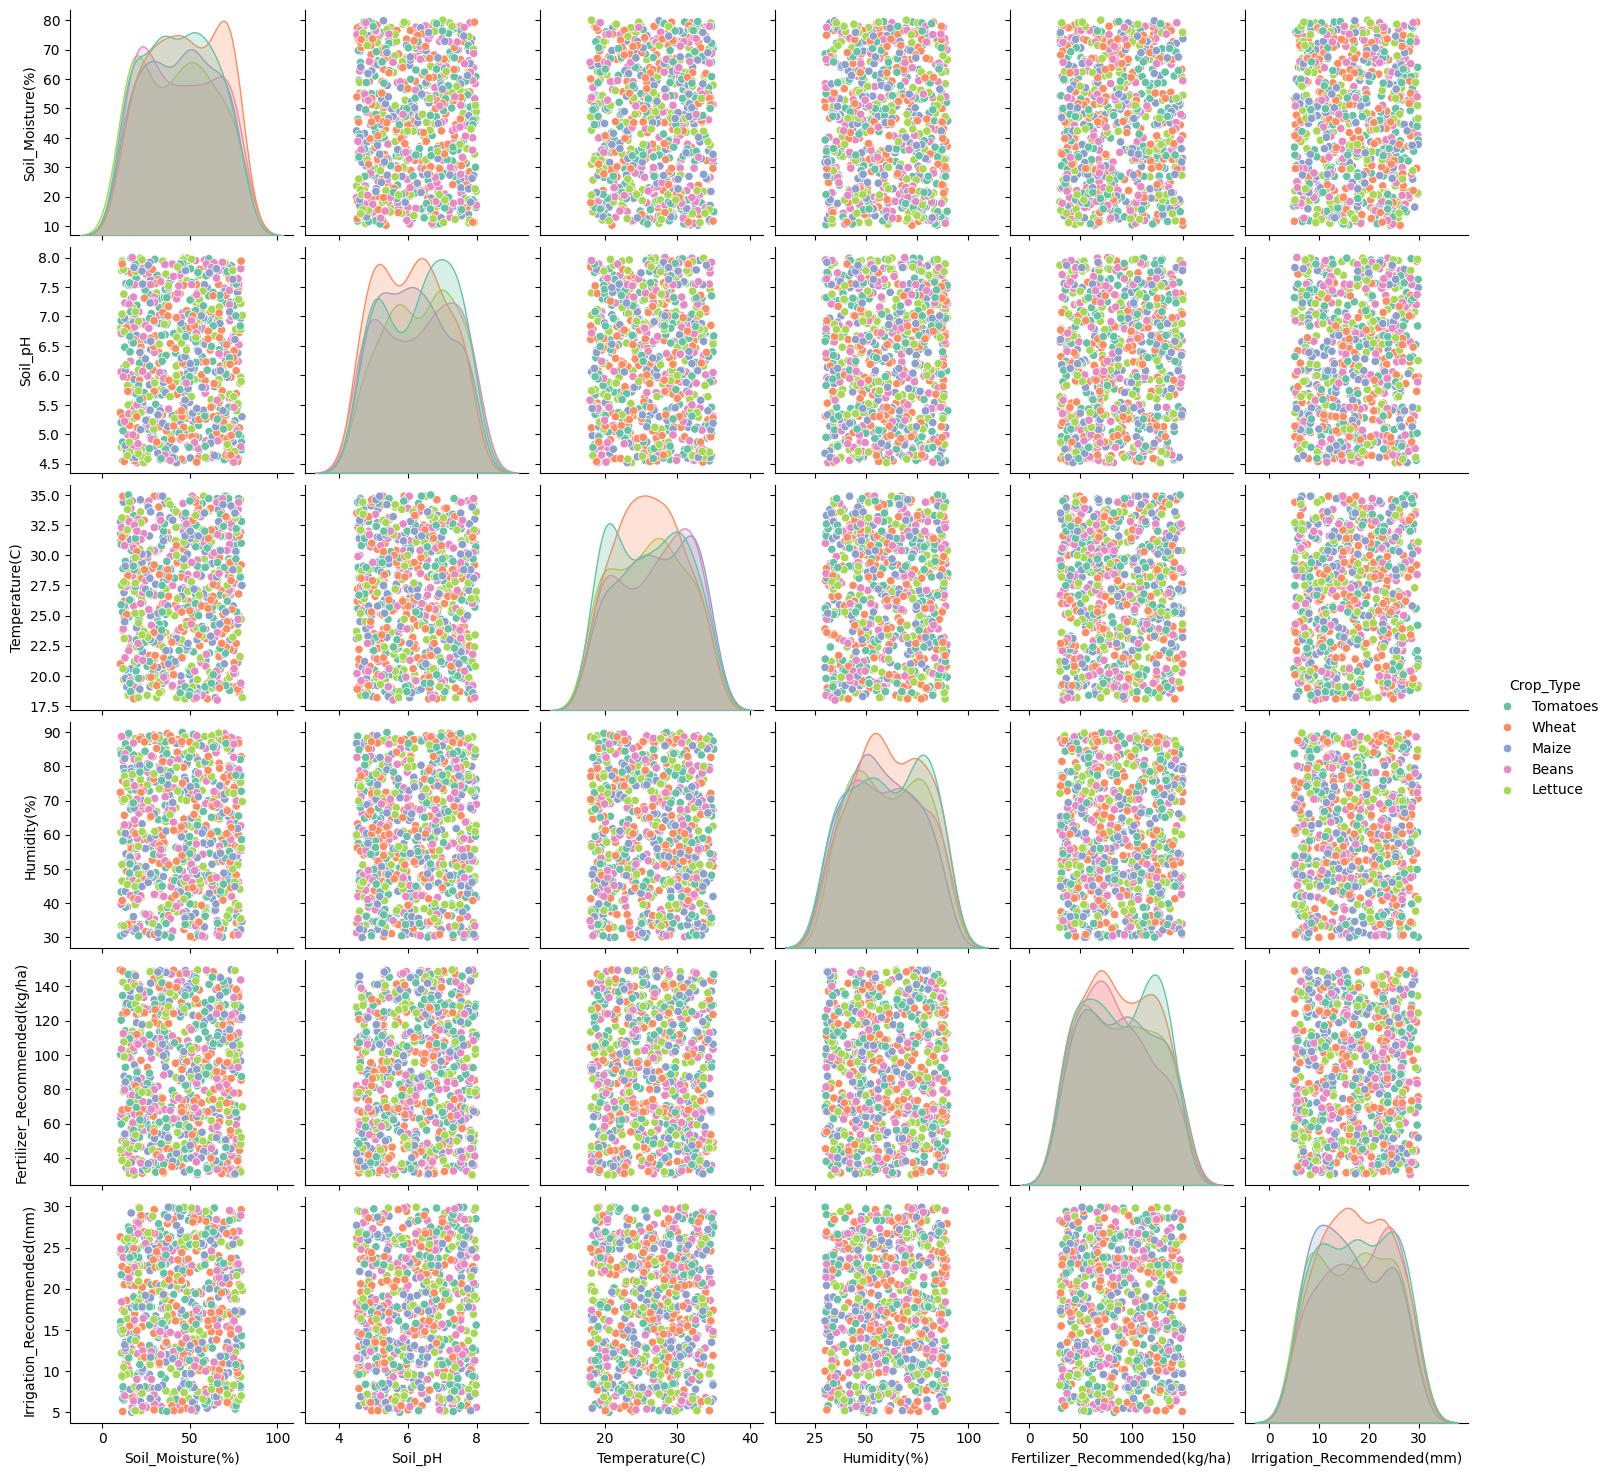

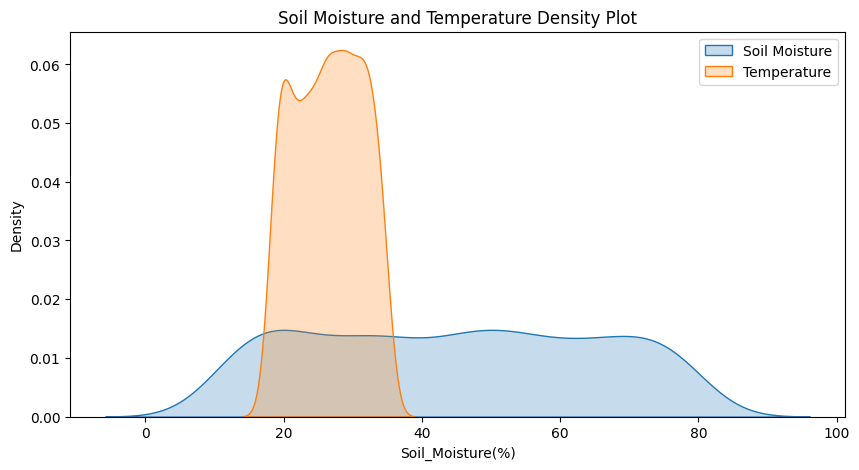

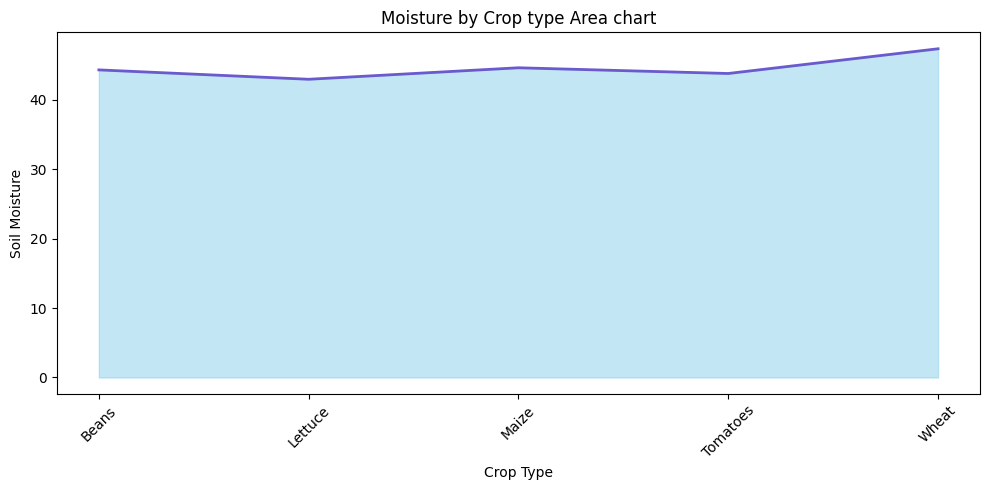

C:\Users\hi\AppData\Local\Temp\ipykernel_11604\863857925.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Crop_Type', palette="Set2")


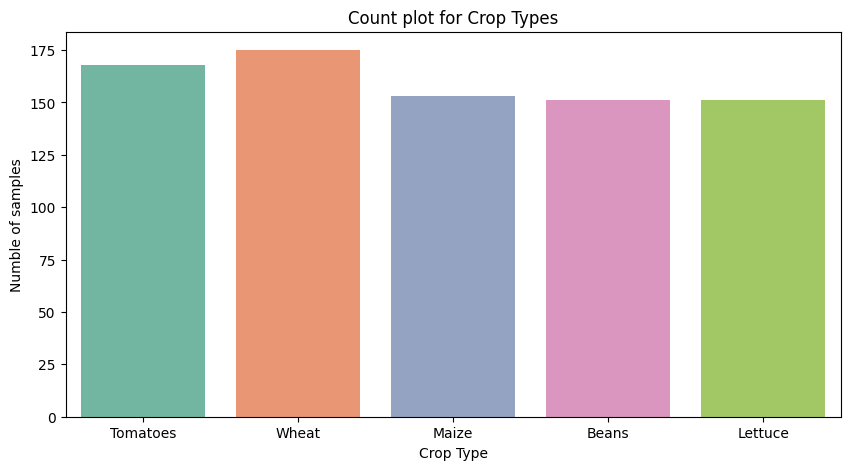

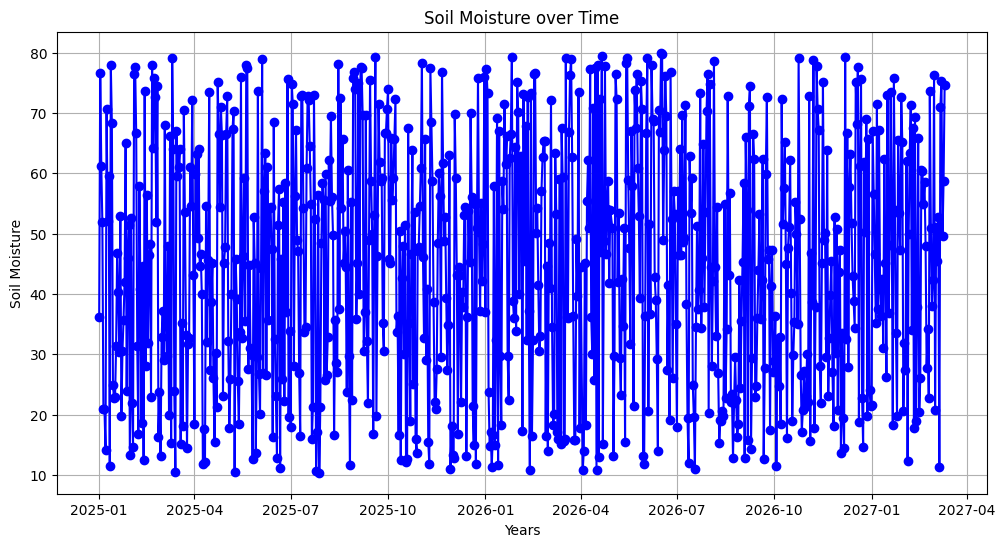

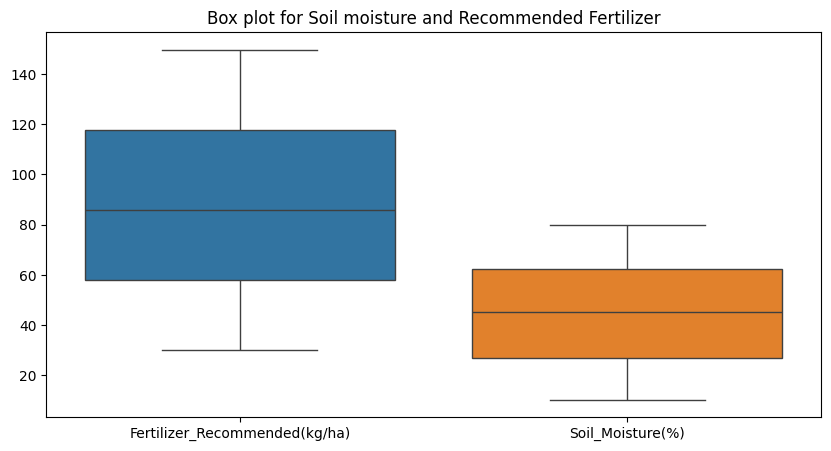

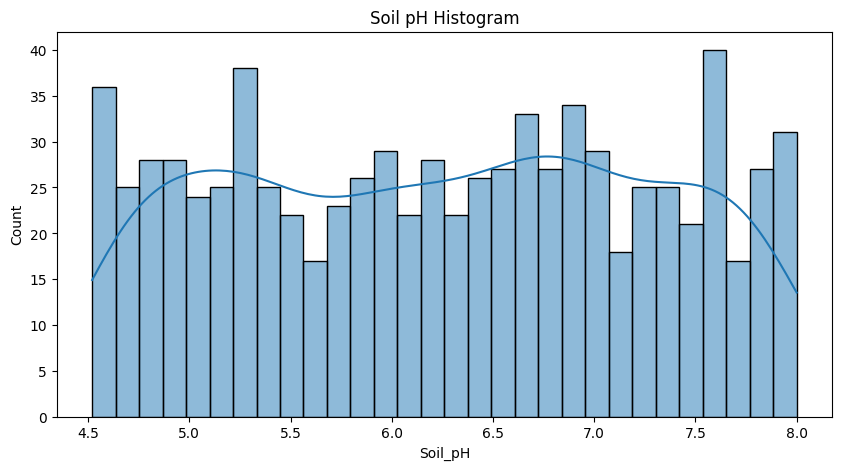

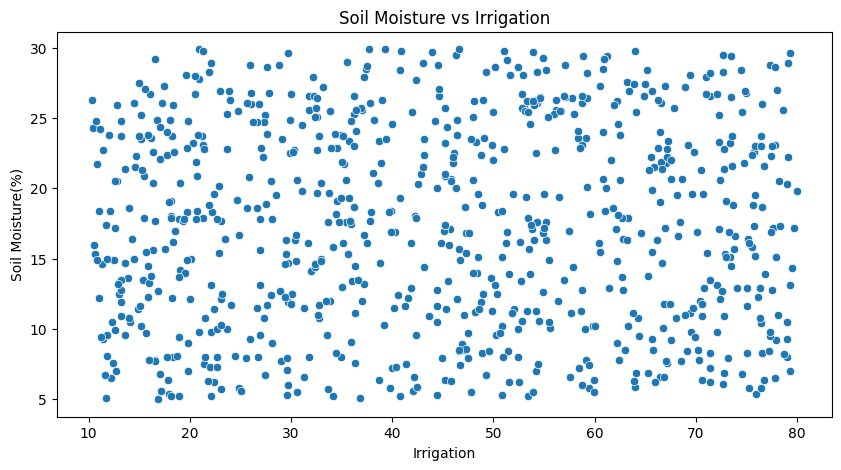

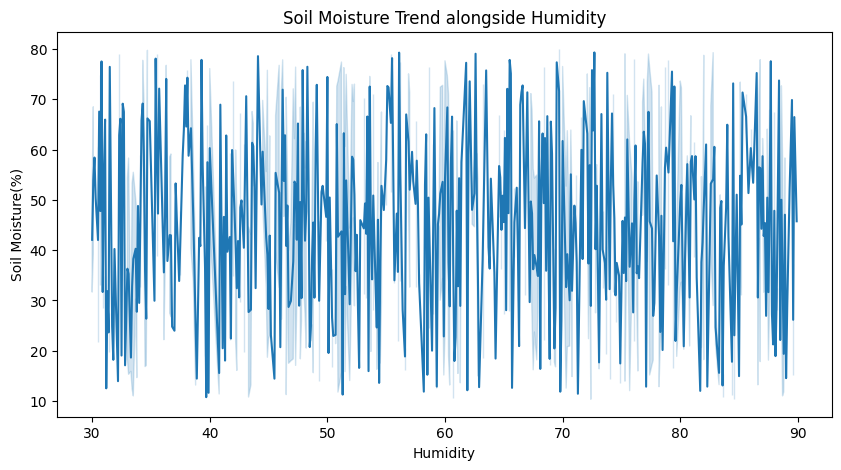

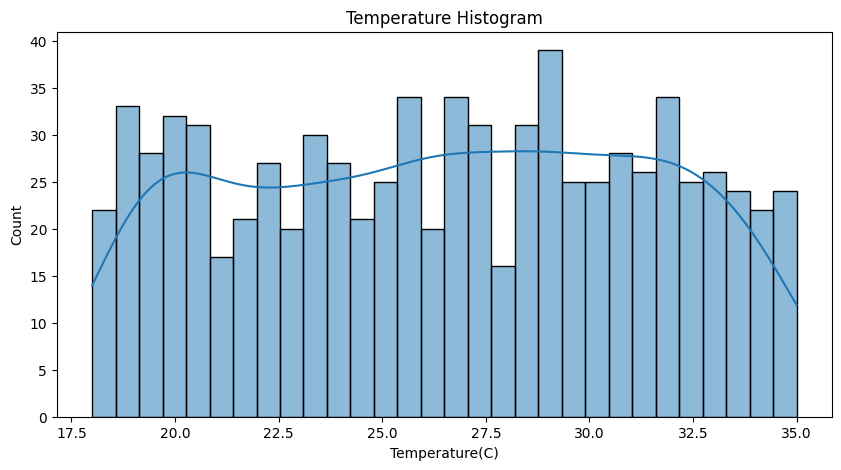

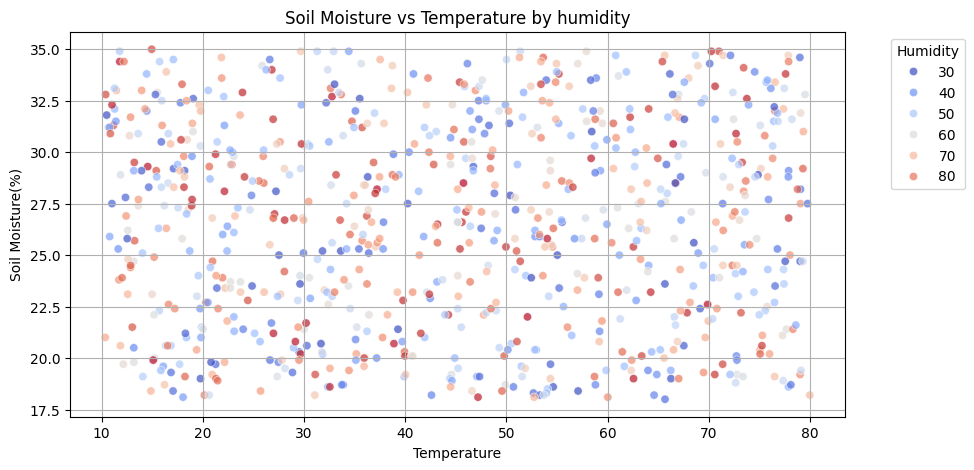

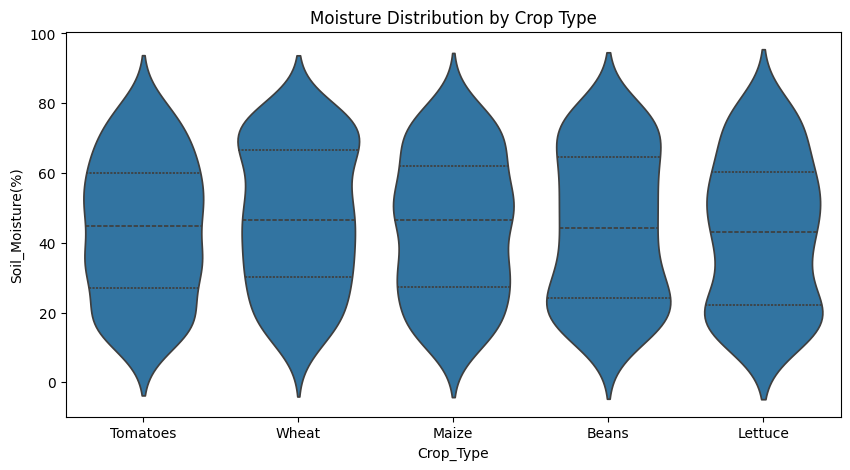

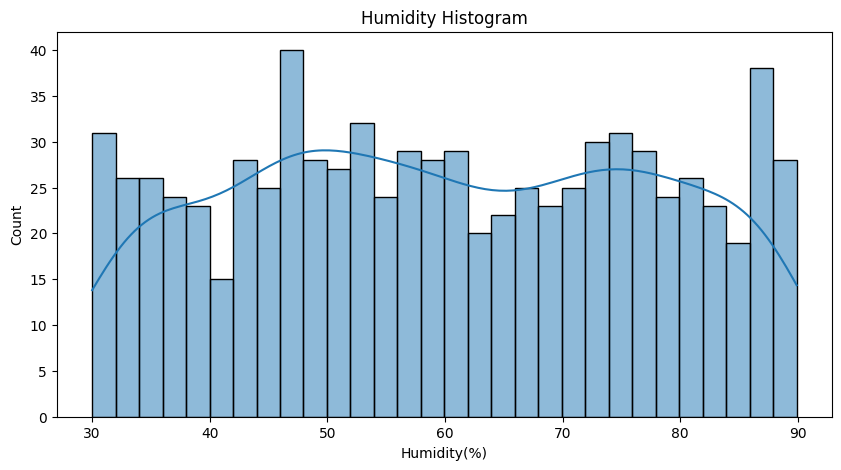

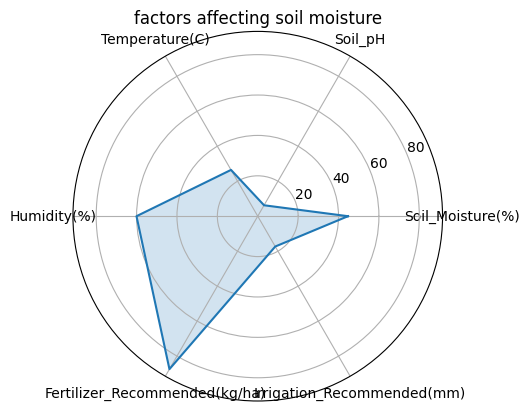

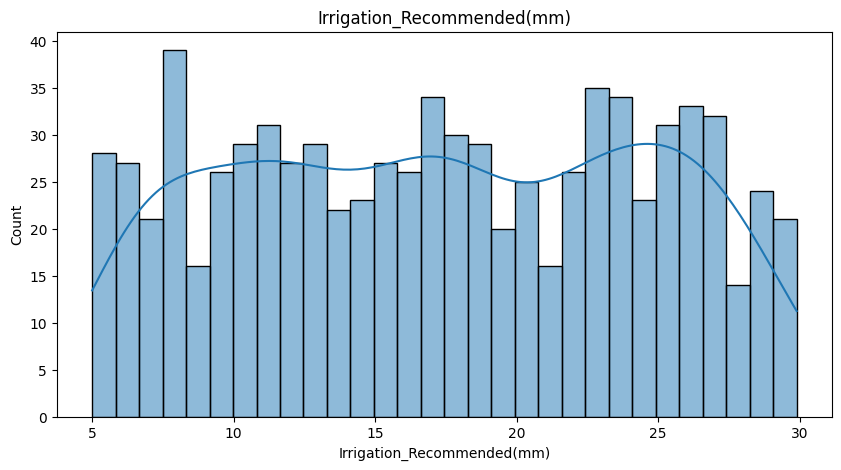

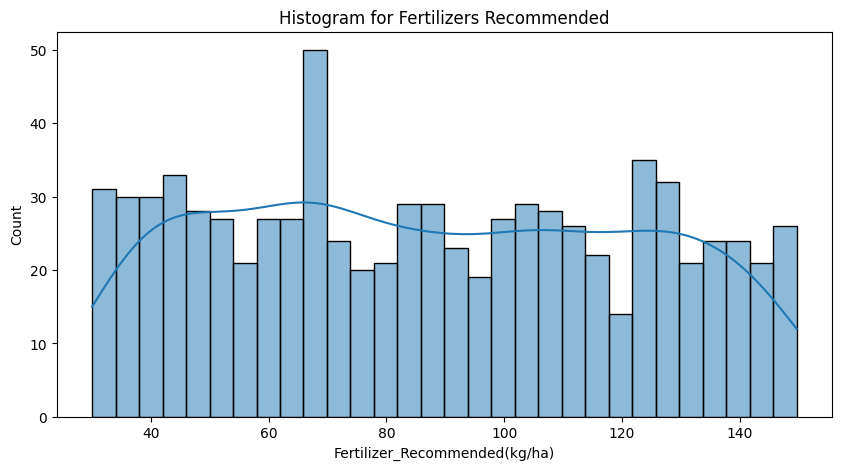

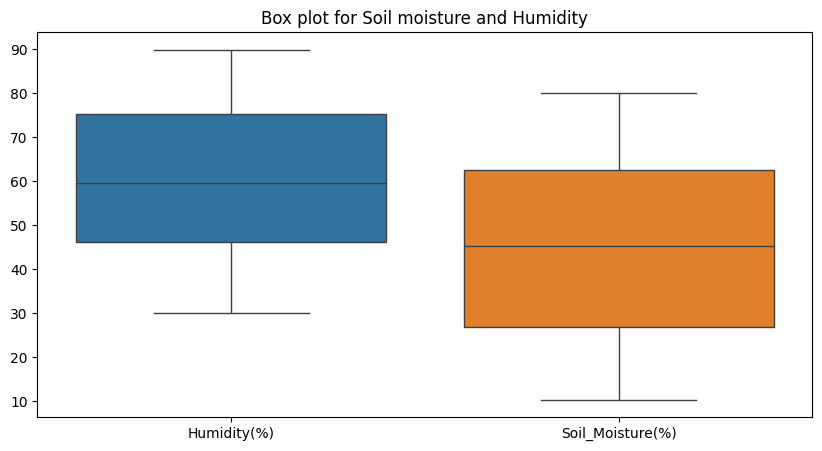

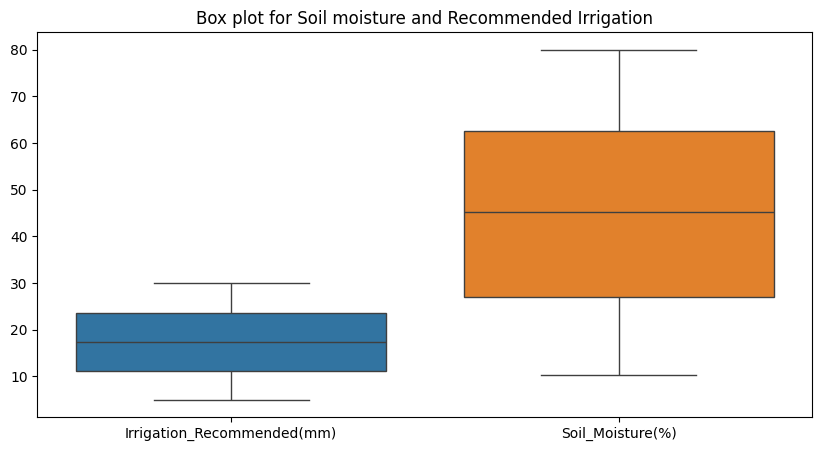

In [110]:
#VISUALIZATIONS

#1.SOIL MOISTURE LINE GRAPH
plt.figure(figsize=(10,5))
sns.lineplot(x=df['Date'], y=df['Soil_Moisture(%)'])
plt.title('Soil Moisture Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Soil Moisture(%)')
plt.show()

#2.SOIL MOISTURE HISTOGRAM
plt.figure(figsize=(10,5))
sns.histplot(df['Soil_Moisture(%)'],bins=30, kde=True)
plt.title('Soil Moisture Histogram')
plt.show()

#3.MOISTURE VS TEMPERATURE SCATTER PLOT
plt.figure(figsize=(10,5))
sns.scatterplot(x=df['Soil_Moisture(%)'], y=df['Temperature(C)'])
plt.title('Soil Moisture vs Temperature')
plt.xlabel('Temperature')
plt.ylabel('Soil Moisture(%)')
plt.show()

#4.BOXPLOT FOR MOISTURE AND TEMPEATURE
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Temperature(C)','Soil_Moisture(%)']])
plt.title('Box plot for Soil moisture and Temperature')
plt.show()

#5.HEATMAP 
plt.figure(figsize=(8,5))
#COMPUTE CORRELATION MATRIX
corr_matrix = df[['Soil_Moisture(%)','Soil_pH','Temperature(C)','Humidity(%)','Fertilizer_Recommended(kg/ha)','Irrigation_Recommended(mm)']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

#6.BARPLOT
plt.figure(figsize=(10,5))
sns.barplot(x='Crop_Type', y='Soil_Moisture(%)',hue='Crop_Type', data=df, palette=['red','green','orange','blue','purple'])
plt.title("Soil Moisture By Crop Type Barplot")
plt.xlabel('Crop Type')
plt.ylabel('Soil Moisture(%)')
plt.show()

#7.CROP TYPE PIECHART
plt.figure(figsize=(6,6))
#count the number of each crop type
crop_count = df['Crop_Type'].value_counts()
plt.pie(crop_count, labels=crop_count.index, colors=['green','red','orange','blue','purple'])
plt.legend(title = 'Crop Types', loc='lower left')
plt.title('Crop Type Distribution')
plt.show()

#8.PAIRPLOT
plt.figure(figsize=(10,5))
sns.pairplot(df, hue='Crop_Type', diag_kind='kde',palette='Set2') 

plt.show()

#9.DENSITYPLOT
plt.figure(figsize=(10,5))
sns.kdeplot(df['Soil_Moisture(%)'], label = 'Soil Moisture', fill=True)
sns.kdeplot(df['Temperature(C)'], label ='Temperature', fill=True)
plt.title("Soil Moisture and Temperature Density Plot")
plt.legend()
plt.ylabel('Density')
plt.show()

#10.AREA CHART
plt.figure(figsize=(10,5))
agg = df.groupby('Crop_Type')['Soil_Moisture(%)'].mean()
plt.fill_between(agg.index, agg.values,color='skyblue', alpha=0.5)
plt.plot(agg.index, agg.values,color='Slateblue', linewidth=2)
plt.title("Moisture by Crop type Area chart")
plt.ylabel("Soil Moisture")
plt.xlabel("Crop Type")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

#11.COUNT PLOT
plt.figure(figsize =(10,5))
sns.countplot(data=df, x='Crop_Type', palette="Set2")
plt.xlabel('Crop Type')
plt.ylabel('Numble of samples')
plt.title("Count plot for Crop Types")
plt.show()

#12.TIMESERIES PLOT
agg = df.groupby('Date')['Soil_Moisture(%)'].mean()
plt.figure(figsize=(12,6))
plt.plot(agg.index,agg.values, marker='o', color='blue')
plt.xlabel('Years')
plt.ylabel('Soil Moisture')
plt.title('Soil Moisture over Time')
plt.grid(True)
plt.show()

#13.BOX PLOT FOR FETRILIZER VS SOIL MOISTURE
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Fertilizer_Recommended(kg/ha)','Soil_Moisture(%)']])
plt.title('Box plot for Soil moisture and Recommended Fertilizer')
plt.show()

#14.HISTOGRAM FOR SOIL PH
plt.figure(figsize=(10,5))
sns.histplot(df['Soil_pH'],bins=30, kde=True)
plt.title('Soil pH Histogram')
plt.show()

#15.SCATTERPLOT FOR SOIL MOISTURE AND IRRIGATION
plt.figure(figsize=(10,5))
sns.scatterplot(x=df['Soil_Moisture(%)'], y=df['Irrigation_Recommended(mm)'])
plt.title('Soil Moisture vs Irrigation')
plt.xlabel('Irrigation')
plt.ylabel('Soil Moisture(%)')
plt.show()

#16.LINE PLOT FOR HUMIDITY
plt.figure(figsize=(10,5))
sns.lineplot(x=df['Humidity(%)'], y=df['Soil_Moisture(%)'])
plt.title('Soil Moisture Trend alongside Humidity')
plt.xlabel('Humidity')
plt.ylabel('Soil Moisture(%)')
plt.show()

#17 TEMPERATURE HISTOGRAM
plt.figure(figsize=(10,5))
sns.histplot(df['Temperature(C)'],bins=30, kde=True)
plt.title('Temperature Histogram')
plt.show()

#18.MOISTURE VS TEMPERATURE SCATTER PLOT
plt.figure(figsize=(10,5))
scatter = sns.scatterplot(x='Soil_Moisture(%)', y='Temperature(C)', hue='Humidity(%)',data=df,palette='coolwarm',alpha=0.7,sizes=(20,200))
plt.title('Soil Moisture vs Temperature by humidity')
plt.xlabel('Temperature')
plt.ylabel('Soil Moisture(%)')
plt.legend(title="Humidity", bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True)
plt.show()

#19.VIOLIN PLOT
plt.figure(figsize=(10,5))
sns.violinplot(x = 'Crop_Type', y='Soil_Moisture(%)',data=df, inner='quartile')
plt.title("Moisture Distribution by Crop Type")
plt.show()

#20.HUMIDITY HISTOGRAM
plt.figure(figsize=(10,5))
sns.histplot(df['Humidity(%)'],bins=30, kde=True)
plt.title('Humidity Histogram')
plt.show()

#21 RADAR CHART

labels = ['Soil_Moisture(%)','Soil_pH','Temperature(C)','Humidity(%)','Fertilizer_Recommended(kg/ha)','Irrigation_Recommended(mm)']
values = [df['Soil_Moisture(%)'].mean(),
          df['Soil_pH'].mean(),
          df['Temperature(C)'].mean(),
          df['Humidity(%)'].mean(),
          df['Fertilizer_Recommended(kg/ha)'].mean(),
          df['Irrigation_Recommended(mm)'].mean()]
values += values[:1]
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.concatenate((angles,[angles[0]]))
fig, ax = plt.subplots(subplot_kw={'polar':True})
ax.plot(angles,values)
ax.fill(angles,values, alpha =0.2)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title("factors affecting soil moisture")
plt.show()

#22IRRIGATION HISTOGRAM
plt.figure(figsize=(10,5))
sns.histplot(df['Irrigation_Recommended(mm)'],bins=30, kde=True)
plt.title('Irrigation_Recommended(mm)')
plt.show()

#23FERTILIZER HISTOGRAM
plt.figure(figsize=(10,5))
sns.histplot(df['Fertilizer_Recommended(kg/ha)'],bins=30, kde=True)
plt.title("Histogram for Fertilizers Recommended")
plt.show()

#24 BOXPLOT FOR MPOISTURE AND HUMIDITY
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Humidity(%)','Soil_Moisture(%)']])
plt.title('Box plot for Soil moisture and Humidity')
plt.show()

#BOXPLOT FOR MOISTURE AND IRRIGATION
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Irrigation_Recommended(mm)','Soil_Moisture(%)']])
plt.title('Box plot for Soil moisture and Recommended Irrigation')
plt.show()